In [1]:
import xarray as xr
import Functions.grid_func as grid_func
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.ticker import MultipleLocator

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
# Load one CMIP6 file
files = '/climca/data/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCESS-CM2/ssp370/r1i1p1f1/day/tas/gn/v20191108/tas_day_ACCESS-CM2_ssp370_r1i1p1f1_gn_20150101-20641231.nc'
nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
nc = nc[['tas']]
nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))
nc = nc.drop_vars('height')
nc_regrid = grid_func.regrid(nc)


In [3]:
# Load one ERA5 file
nc_ERA5 = xr.open_dataset('/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/tas_2015.nc')
nc_ERA5
nc_ERA5_regrid = grid_func.regrid(nc_ERA5)


In [4]:
# Load capacity factor data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')

grid_offshore_sum = grid_offshore['wind_off_cap'].sum() / 1000000
grid_onshore_sum = grid_onshore['wind_on_cap'].sum() / 1000000
grid_solar_sum = grid_solar['solar_cap'].sum() / 1000000

In [5]:
grid_offshore

<xarray.Dataset> Size: 1kB
Dimensions:       (lat: 10, lon: 12)
Coordinates:
  * lat           (lat) int64 80B 47 48 49 50 51 52 53 54 55 56
  * lon           (lon) int64 96B 5 6 7 8 9 10 11 12 13 14 15 16
    crs           int64 8B ...
    gridtype      <U6 24B ...
Data variables:
    wind_off_cap  (lat, lon) float64 960B nan nan nan nan ... nan nan nan nan

In [6]:
nc

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 3653, lat: 12, lon: 6)
Coordinates:
  * time     (time) datetime64[ns] 29kB 2015-01-01T12:00:00 ... 2024-12-31T12...
  * lat      (lat) float64 96B 45.62 46.88 48.12 49.38 ... 56.88 58.12 59.38
  * lon      (lon) float64 48B 6.562 8.438 10.31 12.19 14.06 15.94
Data variables:
    tas      (time, lat, lon) float32 1MB dask.array<chunksize=(1, 12, 6), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP AerChemMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    creation_date:          2019-11-08T10:42:14Z
    ...                     ...
    variable_id:            tas
    variant_label:          r1i1p1f1
    version:                v20191108
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/a9e05595-ad4e-4c63-86e8-cf7ffb09cc95
    license:                CMIP6 model data produced by CSIRO is licensed un...

In [7]:
nc_regrid

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 3653, lat: 10, lon: 12)
Coordinates:
  * time      (time) datetime64[ns] 29kB 2015-01-01T12:00:00 ... 2024-12-31T1...
  * lat       (lat) int64 80B 47 48 49 50 51 52 53 54 55 56
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 96B 5 6 7 8 9 10 11 12 13 14 15 16
Data variables:
    tas       (time, lat, lon) float32 2MB dask.array<chunksize=(1, 10, 12), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

In [8]:
nc_ERA5_regrid

<xarray.Dataset> Size: 4MB
Dimensions:   (time: 8760, lat: 10, lon: 12)
Coordinates:
  * time      (time) datetime64[ns] 70kB 2015-01-01 ... 2015-12-31T23:00:00
  * lat       (lat) int64 80B 47 48 49 50 51 52 53 54 55 56
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 96B 5 6 7 8 9 10 11 12 13 14 15 16
Data variables:
    var167    (time, lat, lon) float32 4MB 271.9 271.4 267.9 ... 0.0 0.0 0.0
Attributes:
    regrid_method:  bilinear

In [9]:
nc_ERA5

<xarray.Dataset> Size: 61MB
Dimensions:  (time: 8760, lon: 47, lat: 37)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2015-01-01 ... 2015-12-31T23:00:00
  * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
  * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
Data variables:
    var167   (time, lat, lon) float32 61MB 266.7 269.2 268.2 ... 276.5 275.7
Attributes:
    CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Apr 03 17:37:15 2024: cdo -f nc -sellonlatbox,3,17,56,4...
    CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...

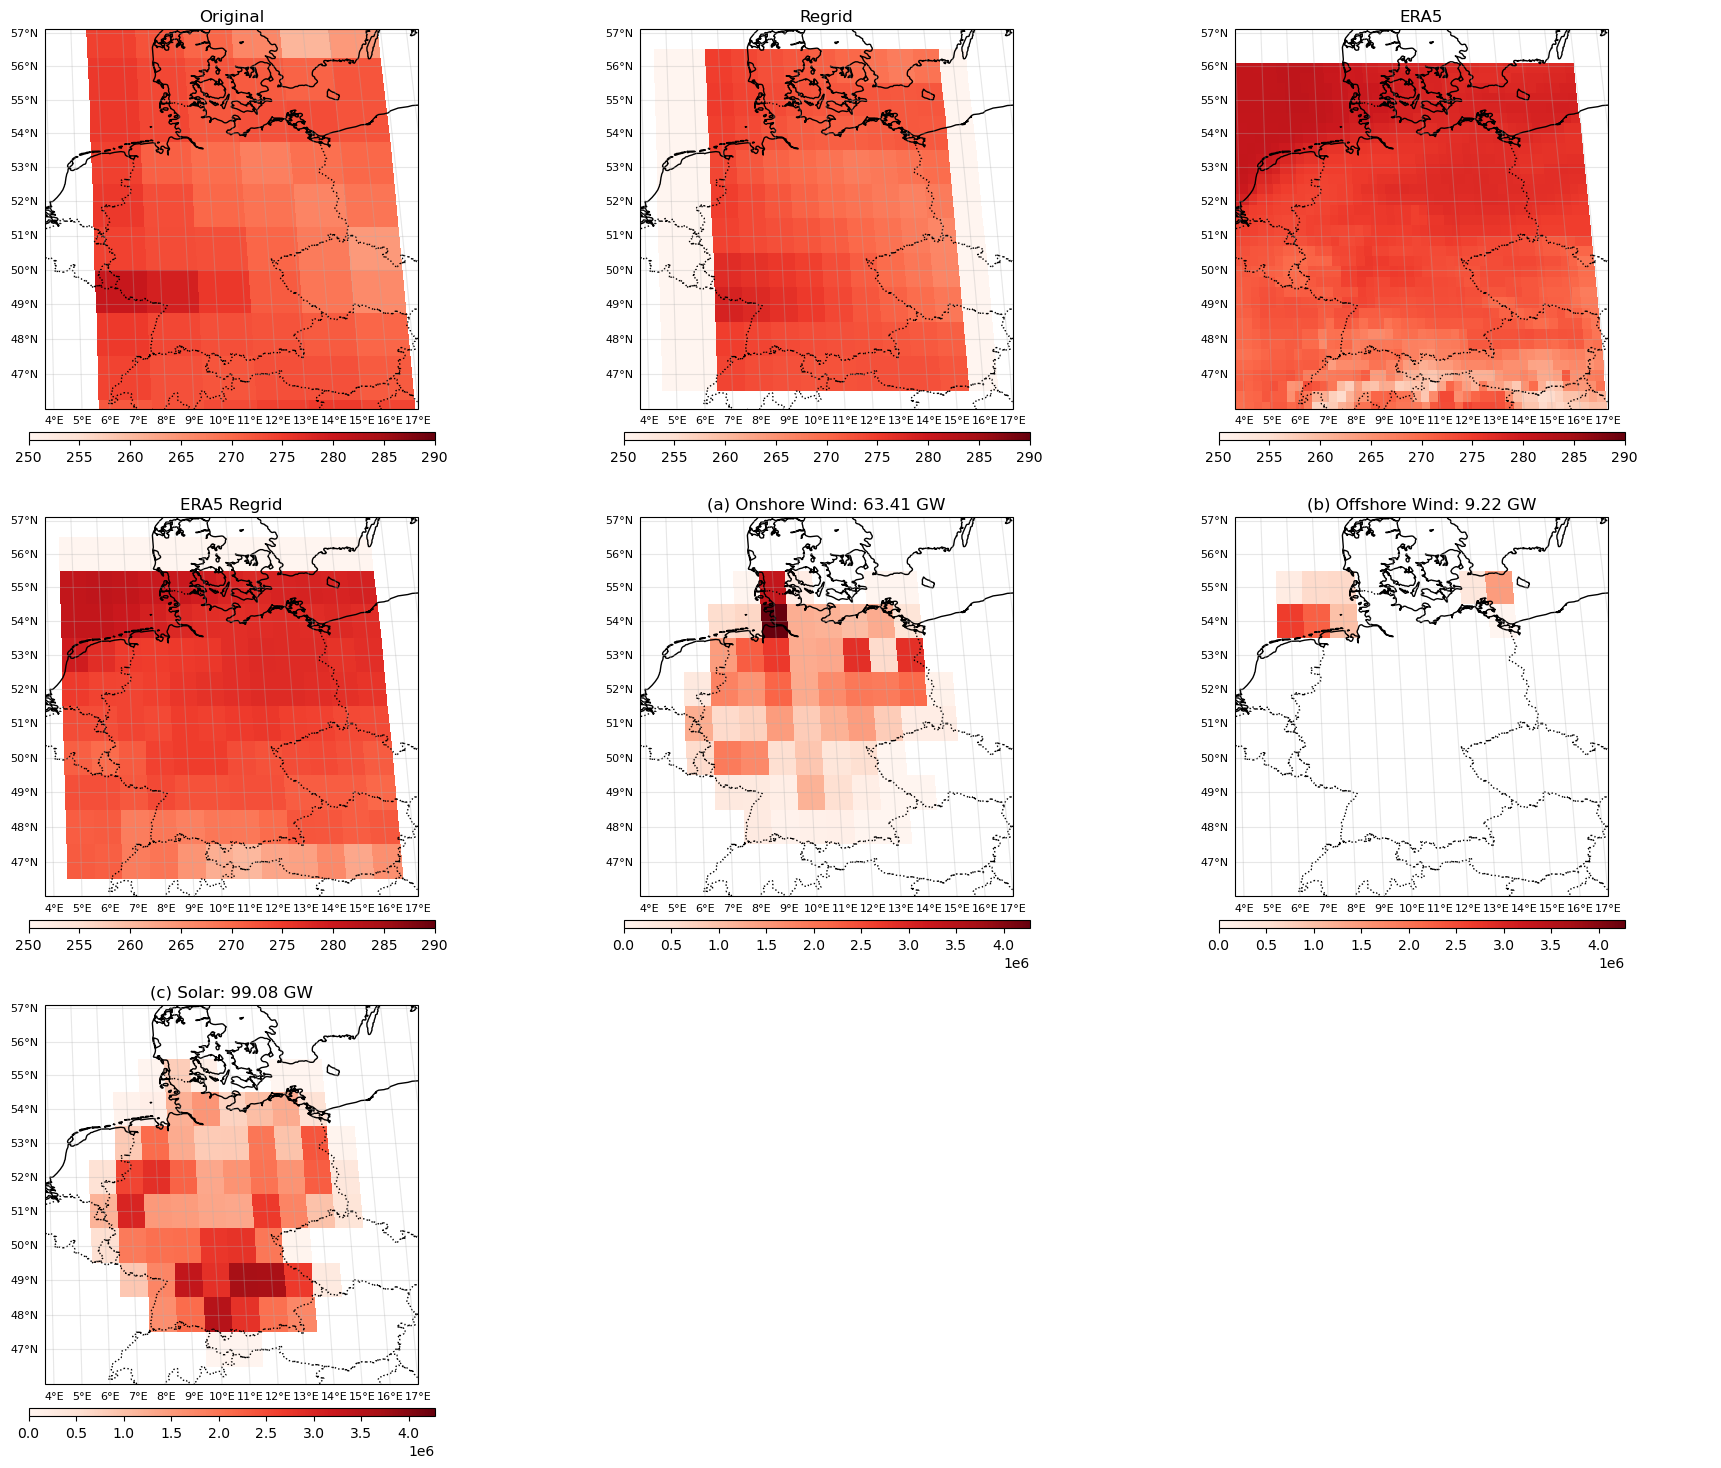

In [10]:

# Prepare edge coordinates
lon_edges   = nc['lon'].values #- (nc['lon'].lon.diff('lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges   = nc['lat'].values #- (nc['lat'].lat.diff('lat') / 2).pad({'lat': (1, 0)}, mode='edge')

lon_edges_2 = nc_regrid['lon'].values #- (nc_regrid['lon'].diff('lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges_2 = nc_regrid['lat'].values #- (nc_regrid['lat'].diff('lat') / 2).pad({'lat': (1, 0)}, mode='edge')

lon_edges_3 = nc_ERA5['lon'].values #- (nc_ERA5['lon'].diff('lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges_3 = nc_ERA5['lat'].values #- (nc_ERA5['lat'].diff('lat') / 2).pad({'lat': (1, 0)}, mode='edge')

lon_edges_4 = nc_ERA5_regrid['lon'].values #- (nc_ERA5_regrid['lon'].diff('lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges_4 = nc_ERA5_regrid['lat'].values #- (nc_ERA5_regrid['lat'].diff('lat') / 2).pad({'lat': (1, 0)}, mode='edge')

xxx1 = grid_onshore['wind_on_cap']
xxx2 = grid_offshore['wind_off_cap']
xxx3 = grid_solar['solar_cap']

# Energy grid edges
lon_edges_energy = grid_offshore.lon.values #- (grid_offshore.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges_energy = grid_offshore.lat.values #- (grid_offshore.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Dataset values
timestep = 1
vmin_temp = 250
vmax_temp = 290


vmin_energy = 0
vmax_energy = max(xxx1.max(), xxx2.max(), xxx3.max())

# Setup 3x3 plot grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15), subplot_kw={'projection': ccrs.Robinson()})
axes = axes.flatten()

# Dataset configurations
datasets = [
    (nc['tas'].isel(time=timestep), lon_edges, lat_edges, 'Original', vmin_temp, vmax_temp),
    (nc_regrid['tas'].isel(time=timestep), lon_edges_2, lat_edges_2, 'Regrid', vmin_temp, vmax_temp),
    (nc_ERA5['var167'].isel(time=timestep), lon_edges_3, lat_edges_3, 'ERA5', vmin_temp, vmax_temp),
    (nc_ERA5_regrid['var167'].isel(time=timestep), lon_edges_4, lat_edges_4, 'ERA5 Regrid', vmin_temp, vmax_temp),
    (xxx1, lon_edges_energy, lat_edges_energy, f'(a) Onshore Wind: {grid_onshore_sum.values:.2f} GW', vmin_energy, vmax_energy),
    (xxx2, lon_edges_energy, lat_edges_energy, f'(b) Offshore Wind: {grid_offshore_sum.values:.2f} GW', vmin_energy, vmax_energy),
    (xxx3, lon_edges_energy, lat_edges_energy, f'(c) Solar: {grid_solar_sum.values:.2f} GW', vmin_energy, vmax_energy)
]

# Plot loop
for ax, (data, lon, lat, title, vmin, vmax) in zip(axes, datasets):
    ax.set_extent([4, 17, 46, 57.1], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
    
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(1)
    gl.ylocator = MultipleLocator(1)

    im = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                       cmap='Reds', vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
    ax.set_title(title)

# Hide any unused subplots (if any remain)
for ax in axes[len(datasets):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

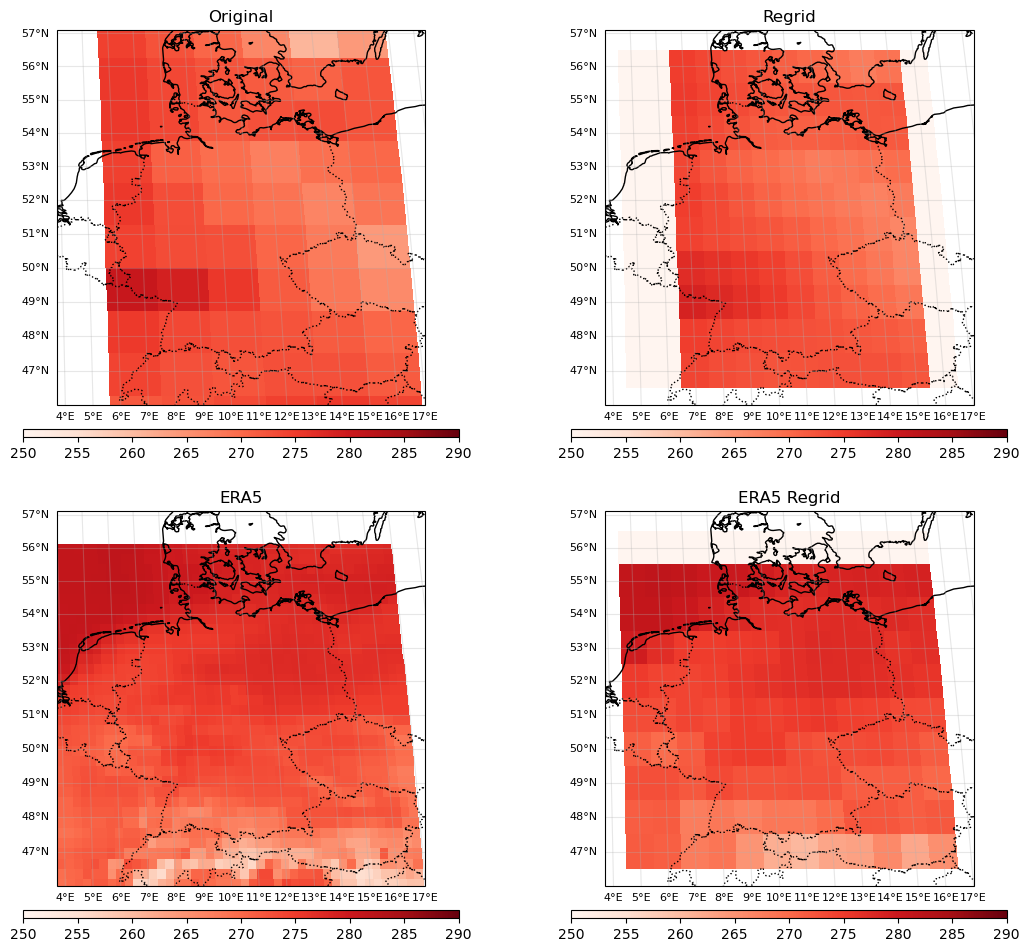

In [11]:
# Compute lon/lat edges for all four datasets
lon_edges   = nc['lon'].values
lat_edges   = nc['lat'].values

lon_edges_2 = nc_regrid['lon'].values
lat_edges_2 = nc_regrid['lat'].values

lon_edges_3 = nc_ERA5['lon'].values
lat_edges_3 = nc_ERA5['lat'].values

lon_edges_4 = nc_ERA5_regrid['lon'].values
lat_edges_4 = nc_ERA5_regrid['lat'].values

vmin = 250
vmax = 290
timestep = 1

# Create a 2x2 subplot layout
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), subplot_kw={'projection': ccrs.Robinson()})
axes = axes.flatten()  # Flatten to access as a list: ax1, ax2, ax3, ax4

# Edge data and titles for each subplot
datasets = [
    (nc['tas'].isel(time=timestep), lon_edges,   lat_edges,   'Original'),
    (nc_regrid['tas'].isel(time=timestep), lon_edges_2, lat_edges_2, 'Regrid'),
    (nc_ERA5['var167'].isel(time=timestep), lon_edges_3, lat_edges_3, 'ERA5'),
    (nc_ERA5_regrid['var167'].isel(time=timestep), lon_edges_4, lat_edges_4, 'ERA5 Regrid'),
]

# Plotting loop
for ax, (data, lon, lat, title) in zip(axes, datasets):
    ax.set_extent([4, 17, 46, 57.1], crs=ccrs.PlateCarree())
    # ax.set_extent([5, 16, 47, 56.1], crs=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(1)
    gl.ylocator = MultipleLocator(1)

    im = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                       cmap='Reds', vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
    ax.set_title(title)

plt.tight_layout()
plt.show()


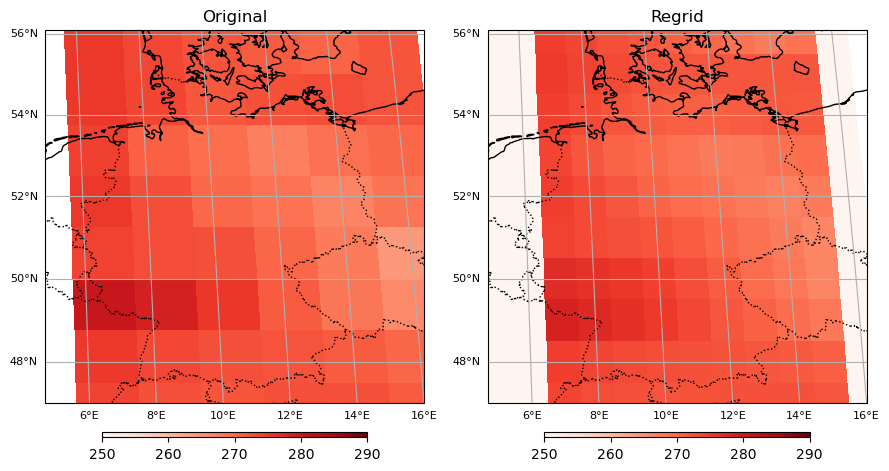

In [13]:
lon_edges = nc['lon'].values #- (nc['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = nc['lat'].values #- (nc['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

lon_edges_2 = nc_regrid['lon'].values #- (nc_regrid['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges_2 = nc_regrid['lat'].values #- (nc_regrid['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 250
vmax = 290
# Plot the data
timestep = 1

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

for ax, lon, lat in zip([ax1, ax2], [lon_edges, lon_edges_2], [lat_edges, lat_edges_2]):
    ax.set_extent([5, 16, 47, 56.1], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=1)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(2)
    gl.ylocator = MultipleLocator(2)


# First subplot
xxx1 = nc['tas'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Original')
# Compute centers
# lon_centers = lon_edges.values
# lat_centers = lat_edges.values
# for i, lat in enumerate(lat_centers):
#     for j, lon in enumerate(lon_centers):
#         value = float(xxx1[i, j].values)
#         ax1.text(lon, lat, f'{value:.1f}', transform=ccrs.PlateCarree(),
#                  ha='center', va='center', fontsize=5, color='black')


# Second subplot
xxx2 = nc_regrid['tas'].isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges_2, lat_edges_2, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Regrid')
# lon_centers_2 = lon_edges_2.values
# lat_centers_2 = lat_edges_2.values
# for i, lat in enumerate(lat_centers_2):
#     for j, lon in enumerate(lon_centers_2):
#         value = float(xxx2[i, j].values)
#         ax2.text(lon, lat, f'{value:.1f}', transform=ccrs.PlateCarree(),
#                  ha='center', va='center', fontsize=5, color='black')


plt.tight_layout()
plt.show()


### Very old

In [14]:
nc['ua'].loc['1850':'1900',:,40:60].resample(time='1Y').mean()

<xarray.DataArray 'ua' (time: 51, plev: 19, lat: 16, lon: 144)>
array([[[[        nan,  1.5425066 ,  1.7864107 , ...,         nan,
                  nan,         nan],
         [        nan,         nan,  1.9388648 , ...,         nan,
                  nan,         nan],
         [        nan,         nan,  0.9927544 , ...,         nan,
                  nan,         nan],
         ...,
         [ 2.5716813 ,  2.3764455 ,  2.0237606 , ...,  3.038986  ,
                  nan,  1.8568051 ],
         [ 2.2677011 ,  1.9959122 ,  1.3498756 , ...,  3.0392132 ,
           2.087933  ,  2.4539955 ],
         [ 2.374237  ,  2.0340645 ,  0.8988264 , ...,  2.638821  ,
           2.6554773 ,  2.6097806 ]],

        [[ 1.9526247 ,  2.313747  ,  2.4139245 , ...,  1.3353728 ,
           0.91430897,         nan],
         [ 2.4333389 ,  2.298568  ,  2.734231  , ...,  0.20493622,
           0.5563985 ,  2.64294   ],
         [ 1.055844  ,  2.3652751 ,  1.7698399 , ...,  1.4414333 ,
           0.92084765,  2.2963548 ],
...
         [17.991102  , 17.91688   , 17.876131  , ..., 18.35103   ,
          18.197605  , 18.085669  ],
         [17.267132  , 17.17547   , 17.10282   , ..., 17.61804   ,
          17.484488  , 17.372965  ],
         [16.394012  , 16.274836  , 16.085989  , ..., 16.75583   ,
          16.630793  , 16.512438  ]],

        [[16.786734  , 16.628483  , 16.46641   , ..., 17.368933  ,
          17.20946   , 16.999994  ],
         [18.043488  , 17.907114  , 17.785963  , ..., 18.433922  ,
          18.298288  , 18.15492   ],
         [18.961771  , 18.887243  , 18.837702  , ..., 19.266264  ,
          19.15503   , 19.029371  ],
         ...,
         [17.175365  , 17.074013  , 17.056723  , ..., 17.602098  ,
          17.38727   , 17.259714  ],
         [16.689505  , 16.605635  , 16.569456  , ..., 17.041954  ,
          16.908228  , 16.788757  ],
         [16.317595  , 16.22151   , 16.00152   , ..., 16.404535  ,
          16.413347  , 16.389874  ]]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 40.56 41.83 43.1 44.37 ... 55.77 57.04 58.31 59.58
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * plev     (plev) float32 1e+05 9.25e+04 8.5e+04 7e+04 ... 1e+03 500.0 100.0
  * time     (time) datetime64[ns] 1850-12-31 1851-12-31 ... 1900-12-31
Attributes:
    long_name:           Eastward Wind
    units:               m s-1
    online_operation:    average
    cell_methods:        time: mean
    interval_operation:  900 s
    interval_write:      1 month
    standard_name:       eastward_wind
    description:         Eastward Wind
    history:             none
    cell_measures:       area: areacella

/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


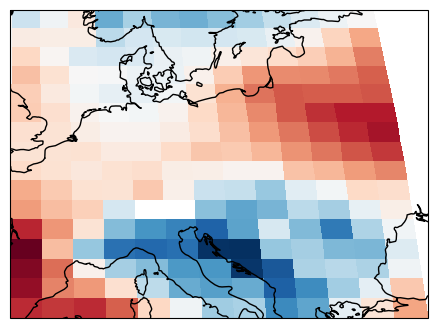

In [6]:
fig,ax = plt.subplots(nrows=1, figsize=(12, 4), subplot_kw={'projection': cartopy.crs.Robinson()})
ax.coastlines()
xxx = nc['ua'].loc['2008-02-15T12:00:00',85000,40:60, 0:30]
im = ax.pcolormesh(xxx.lon, xxx.lat, xxx * 10, transform=cartopy.crs.PlateCarree(), cmap='RdBu_r')